# NLP Project 2

**ESILV A4 DIA6 — 2026**



**Authors:** Leo WINTER & Alvaro SERERO

## Table of Contents   
1. [Setup & Imports](#setup)
2. [Load Data](#load)
3. [Word2Vect model](#w2_vect)
    - 3.1 [Model](#w2_vect_model)
    - 3.2 [Training](#w2_vect_train)
    - 3.3 [testing the embeddings](#w2_vect_test)
3. [Glove model](#glove)
    - 3.1 [Model](#glove_model)
    - 3.2 [testing the embeddings](#glove_test)

<a id="setup"></a>
## 1. Setup & Imports

In [69]:
# Faudrait peut-être entrainer les données sur tout le dataset et pas 
# just sur les 20000 car on s'en fout de ne pas avoir les étoiles
# et pour des meilleurs embeddings c'est mieux

from pathlib import Path
import os
import pickle
import ast
import webbrowser
import time

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import gensim.downloader
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from gensim.models import KeyedVectors

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorboard.plugins import projector

# Setting up the Paths
CURRENT_DIR = Path.cwd()
DATA_PATH = CURRENT_DIR.parent / "data"
MODEL_PATH = CURRENT_DIR.parent / "model"
VISU_PATH = CURRENT_DIR.parent / "visualizations" / "notebook2"
LOG_DIR = CURRENT_DIR.parent / "logs" / "projector"
MODEL_PATH.mkdir(exist_ok=True)
VISU_PATH.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

In [85]:
def setup_tensorboard_projector(model_instance,log_name: str):
    log_path = str(LOG_DIR / log_name)
    os.makedirs(log_path, exist_ok=True)
    metadata_path = os.path.join(log_path, 'metadata.tsv')
    with open(metadata_path, 'w', encoding='utf-8') as f:
        for word in model_instance.getVocabList():
            f.write(word + '\n')

    weights = tf.Variable(model_instance.model.wv.vectors)
    checkpoint = tf.train.Checkpoint(embedding=weights)
    checkpoint.save(os.path.join(log_path, "embedding.ckpt"))

    config = projector.ProjectorConfig()
    embedding = config.embeddings.add()
    embedding.tensor_name = "embedding/.ATTRIBUTES/VARIABLE_VALUE"
    embedding.metadata_path = 'metadata.tsv'
    projector.visualize_embeddings(log_path, config)
    with open(os.path.join(log_path, "projector_config.pbtxt"), "a") as f:
        f.write('\nmodel_checkpoint_path: "embedding.ckpt-1"')

def launch_projector(log_name):
    log_path = str(LOG_DIR / log_name)
    cmd = f"tensorboard --logdir={log_path} --port=6006"
    print(f"Starting TensorBoard on {log_path}")

    os.popen(cmd)
    time.sleep(3)
    webbrowser.open("http://localhost:6006/")
    print("TensorBoard successfully launched")


<a id="load"></a>
## 2. Load Data

In [2]:
# Load data saved in the fisrt notebook
def load_data():
    path_parquet = DATA_PATH / "reviews_clean.parquet"
    path_csv = DATA_PATH / "reviews_clean.csv"

    if path_parquet.exists():
        try:
            df = pd.read_parquet(path_parquet)
            return df
        except Exception as e:
            print(e)

    if path_csv.exists():
        try:
            df = pd.read_csv(path_csv)
            return df
        except Exception as e:
            print(e)
    return None

In [3]:
dataset = load_data()
if dataset is not None:
    display(dataset.head(2))
else:
    print("Error, no dataset files found")

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,year_month,tokens_en,tokens
0,5,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,2021-09-06,2021-09-01,"Best insurance, price, solutions, listening, s...",meilleurs assurances prix solutions écoute rap...,best insurance price solutions listening speed...,2021-09,"['good', 'price', 'solution', 'listen', 'speed...","['meilleur', 'prix', 'solution', 'écoute', 'ra..."
1,4,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,2021-05-03,2021-05-01,"I am generally satisfied, except that you have...",je suis globalement satisfait sauf que vous av...,i am generally satisfied except that you have ...,2021-05,"['generally', 'satisfied', 'except', 'problem'...","['globalement', 'satisfait', 'sauf', 'problème..."


<a id="w2_vect"></a>
## 3. Word2Vect model

<a id="w2_vect_model"></a>
### 3.1 Model

In [ ]:
class TqdmCallback(CallbackAny2Vec):
    def __init__(self, total_epochs):
        self.pbar = tqdm(total=total_epochs, desc="Word2Vec")
        self.epoch = 0

    def on_epoch_end(self, model):
        self.epoch += 1
        self.pbar.update(1)
        if self.epoch == self.pbar.total:
            self.pbar.close()

class Word2VecModel:
    def __init__(self, vector_size=100, window=5, min_count=2, sg=1, epochs=10):
        """
        :param vector_size: Vector dimension
        :param window: Contex size
        :param min_count: Minimum apparition of words
        :param sg: 1 for Skip-Gram, 0 for CBOW
        """
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.sg = sg
        self.epochs = epochs
        self.model = None

    def train(self, data):
        monitor = TqdmCallback(self.epochs)
        self.model = Word2Vec(
            sentences=data, 
            vector_size=self.vector_size, 
            window=self.window, 
            min_count=self.min_count, 
            workers=4,
            epochs=self.epochs,
            sg=self.sg,
            callbacks=[monitor]
        )
        return self.model

    def save_model(self, file_name):

        if self.model is not None:
            file_path = str(MODEL_PATH / f"{file_name}.model")
            self.model.save(file_path)
            print(f"Model saved")
        else:
            print("Error, no model found")

    def load_model(self, file_name):
        file_path = str(MODEL_PATH / f"{file_name}.model")
        if os.path.exists(file_path):
            self.model = Word2Vec.load(file_path)
            print("Model successfully loaded")
            return self.model
        else:
            print("Model not found")

    def isVec(self,word):
        if self.model is None:
            print("Model not trained")
            return False
        
        return word in self.model.wv
    
    def getVec(self,word):
        if self.model is None:
            print("Model not trained")
            return np.zeros(self.vector_size)
        
        return self.model.wv[word]

    def getId(self,word):
        if self.model is None:
            print("Model not trained")
            return -1
        
        return self.model.wv.key_to_index[word]

    def getWord(self,id):
        if self.model is None:
            print("Model not trained")
            return None
        
        return self.model.wv.index_to_key[id]

    def getVocabList(self):
        if self.model is None:
            print("Model not trained")
            return None
        
        return self.model.wv.index_to_key

    def getVocabDic(self):
        if self.model is None:
            print("Model not trained")
            return None
        
        return self.model.wv.key_to_index

    def getLenVocab(self):
        if self.model is None:
            print("Model not trained")
            return None
        
        return len(self.model.wv.index_to_key)

    def nbDims(self):
            return self.vector_size
            
    def get_euclidean_distance(self, word1, word2):
        if self.model is None:
            print("Model not trained")
            return None
        
        if self.isVec(word1) and self.isVec(word2):
            v1 = self.getVec(word1)
            v2 = self.getVec(word2)
            return np.linalg.norm(v1 - v2)
        return None

    def get_cosine_similarity(self, word1, word2):
        if self.model is None:
            print("Model not trained")
            return None
        
        if self.isVec(word1) and self.isVec(word2):
            v1 = self.getVec(word1)
            v2 = self.getVec(word2)
            return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return None
    
    def plot_2d_embeddings(self, words_to_plot, name: str = "2D_embeddings_w2v"):
        if self.model is None:
            print("Model not trained")
            return None

        valid_words = [word for word in words_to_plot if self.isVec(word)]
        if not valid_words:
            return None
        vectors = np.array([self.getVec(word) for word in valid_words])
        
        pca = PCA(n_components=2)
        result = pca.fit_transform(vectors)
    
        plt.scatter(result[:, 0], result[:, 1], color='blue', edgecolors='k')
        for i, word in enumerate(words_to_plot):
            plt.annotate(word, xy=(result[i, 0], result[i, 1]),
                         xytext=(5, 2), textcoords='offset points')
        plt.title(f"2D word embeddings")
        plt.savefig(VISU_PATH / f"{name}.png", bbox_inches="tight")
        plt.show()
    
    def get_sentence_vector(self, sentence):
        if self.model is None:
            print("Model not trained")
            return None
        
        words = sentence.split() if isinstance(sentence, str) else sentence
        valid_vectors = [self.getVec(word) for word in words if self.isVec(word)]
        if not valid_vectors:
            return None
    
        return np.mean(valid_vectors, axis=0)
    

    def semantic_search(self, query, corpus_vectors, top_n=3):
        if self.model is None:
            print("Model not trained")
            return None
        
        query_vec = self.get_sentence_vector(query)
        if query_vec is None: return "Unknown words"

        corpus_matrix = np.array(corpus_vectors)
        dot_product = np.dot(corpus_matrix, query_vec)
        norms = np.linalg.norm(corpus_matrix, axis=1) * np.linalg.norm(query_vec)
        similarities = dot_product / norms

        return np.argsort(similarities)[-top_n:][::-1]


<a id="w2_vect_train"></a>
### 3.2 Training 

In [ ]:
# only run if the models are not trained
if dataset is not None:

    data_pour_w2v_en = [ast.literal_eval(text) 
                        if isinstance(text, str) 
                        else text for text in dataset['tokens_en']]
    data_pour_w2v_fr = [ast.literal_eval(text) 
                        if isinstance(text, str) 
                        else text for text in dataset['tokens']]

    model_w2v_en = Word2VecModel()
    model_w2v_fr = Word2VecModel()

    model_w2v_en.train(data_pour_w2v_en)
    model_w2v_fr.train(data_pour_w2v_fr)

    model_w2v_en.save_model("word2vec_en")
    model_w2v_fr.save_model("word2vec_fr")

Word2Vec: 100%|██████████| 10/10 [00:14<00:00,  1.45s/it]

Model saved
Model saved


<a id="w2_vect_test"></a>
### 3.3 Testing the embeddings

In [ ]:
try:
    if model_w2v_fr.model is None:
        model_w2v_fr.load_model("word2vec_fr")
except NameError:
    model_w2v_fr = Word2VecModel()
    model_w2v_fr.load_model("word2vec_fr")

try:
    if model_w2v_en.model is None:
        model_w2v_en.load_model("word2vec_en")
except NameError:
    model_w2v_en = Word2VecModel()
    model_w2v_en.load_model("word2vec_en")

print(f"\n                             English model")
print(f"Number of dimension => {model_w2v_en.nbDims()}")
print(f"Number of words covered by the embedding => {model_w2v_en.getLenVocab()}")

print(f"\n                             French model")
print(f"Number of dimension => {model_w2v_fr.nbDims()}")
print(f"Number of words covered by the embedding => {model_w2v_fr.getLenVocab()}")


                             English model
Number of dimension =>100
Number of words covered by the embedding =>7606

                             French model
Number of dimension =>100
Number of words covered by the embedding =>12745


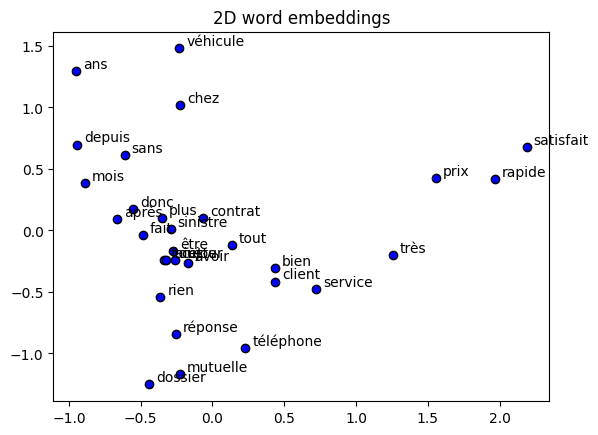

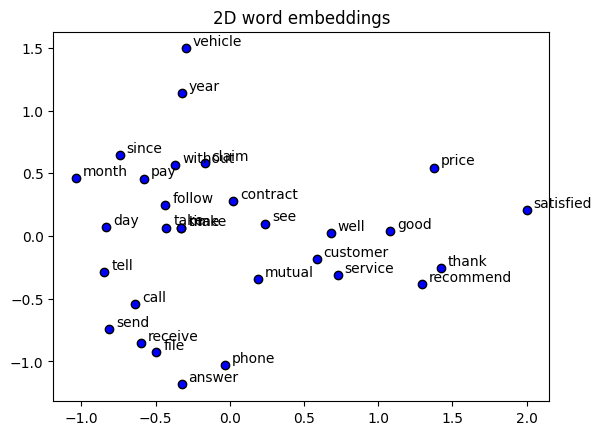

In [7]:
model_w2v_fr.plot_2d_embeddings(model_w2v_fr.model.wv.index_to_key[:30]
                                ,"Top_word_2D_embeddings_w2v_fr")
model_w2v_en.plot_2d_embeddings(model_w2v_en.model.wv.index_to_key[:30]
                                ,"Top_word_2D_embeddings_w2v_en")

In [14]:
sim_good_en = model_w2v_en.get_cosine_similarity("price", "attractive")
dist_good_en = model_w2v_en.get_euclidean_distance("price", "attractive")
sim_good_fr = model_w2v_fr.get_cosine_similarity("prix", "attractif")
dist_good_fr = model_w2v_fr.get_euclidean_distance("prix", "attractif")

sim_bad_en = model_w2v_en.get_cosine_similarity("price", "answer")
dist_bad_en = model_w2v_en.get_euclidean_distance("price", "answer")
sim_bad_fr = model_w2v_fr.get_cosine_similarity("prix", "réponse")
dist_bad_fr = model_w2v_fr.get_euclidean_distance("prix", "réponse")

sim_med_en = model_w2v_en.get_cosine_similarity("price", "cost")
dist_med_en = model_w2v_en.get_euclidean_distance("price", "cost")
sim_med_fr = model_w2v_fr.get_cosine_similarity("prix", "coût")
dist_med_fr = model_w2v_fr.get_euclidean_distance("prix", "coût")


print(f"                             English model")
print((f"Price vs Attractive | Cosinus sim: {sim_good_en:.4f}"
       f" | Euclidienne dist: {dist_good_en:.4f}"))
print((f"Price vs Answer     | Cosinus sim: {sim_bad_en:.4f}"
       f" | Euclidienne dist: {dist_bad_en:.4f}"))
print((f"Price vs Cost       | Cosinus sim: {sim_med_en:.4f}"
       f" | Euclidienne dist: {dist_med_en:.4f}"))

print(f"\n                             French model")
print((f"Prix vs Attractif | Cosinus sim: {sim_good_fr:.4f}"
       f" | Euclidienne dist: {dist_good_fr:.4f}"))
print((f"Prix vs Réponse   | Cosinus sim: {sim_bad_fr:.4f}"
       f" | Euclidienne dist: {dist_bad_fr:.4f}"))
print((f"Prix vs Coût      | Cosinus sim: {sim_med_fr:.4f}"
       f" | Euclidienne dist: {dist_med_fr:.4f}"))

                             English model
Price vs Attractive | Cosinus sim: 0.7125 | Euclidienne dist: 2.4134
Price vs Answer     | Cosinus sim: 0.2866 | Euclidienne dist: 3.3982
Price vs Cost       | Cosinus sim: 0.3311 | Euclidienne dist: 3.5813

                             French model
Prix vs Attractif | Cosinus sim: 0.6655 | Euclidienne dist: 2.7223
Prix vs Réponse   | Cosinus sim: 0.2496 | Euclidienne dist: 3.9338
Prix vs Coût      | Cosinus sim: 0.5114 | Euclidienne dist: 3.1755


In [15]:
if dataset is None: 
    dataset = pd.DataFrame() #To not have None warnings
data_pour_w2v_en = [ast.literal_eval(text) 
                        if isinstance(text, str) 
                        else text for text in dataset['tokens_en']]

all_vectors_raw_en = [model_w2v_en.get_sentence_vector(rev) for rev in data_pour_w2v_en]
valid_data_en = {i: vec for i, vec in enumerate(all_vectors_raw_en) if vec is not None}
clean_vectors_en = list(valid_data_en.values())
clean_indices_en = list(valid_data_en.keys())

data_pour_w2v_fr = [ast.literal_eval(text) 
                        if isinstance(text, str) 
                        else text for text in dataset['tokens']]

all_vectors_raw_fr = [model_w2v_en.get_sentence_vector(rev) for rev in data_pour_w2v_en]
valid_data_fr = {i: vec for i, vec in enumerate(all_vectors_raw_fr) if vec is not None}
clean_vectors_fr = list(valid_data_fr.values())
clean_indices_fr = list(valid_data_fr.keys())

In [16]:
query = "very expensive insurance"
results = model_w2v_en.semantic_search(query, clean_vectors_en)

print(f"        Query <{query}> :\n")
for rank, idx_in_clean in enumerate(results):
    original_idx = clean_indices_en[idx_in_clean]
    avis_texte = dataset['tokens_en'].iloc[original_idx]
    print(f"Top {rank+1}-Avis n°{original_idx}: {avis_texte}")

print("\n\n")
query = "assurance très chère"
results = model_w2v_fr.semantic_search(query, clean_vectors_fr)

print(f"        Query <{query}> :\n")
for rank, idx_in_clean in enumerate(results):
    original_idx = clean_indices_fr[idx_in_clean]
    avis_texte = dataset['tokens'].iloc[original_idx]
    print(f"Top {rank+1}-Avis n°{original_idx}: {avis_texte}")

        Query <very expensive insurance> :

Top 1-Avis n°14121: ['far', 'expensive']
Top 2-Avis n°5405: ['price', 'expensive', 'think', 'chef', 'expensive', 'france', 'french', 'increasingly', 'poor', 'think', 'price', 'expensive']
Top 3-Avis n°21372: ['expensive', 'gan', 'service']



        Query <assurance très chère> :

Top 1-Avis n°5670: ['client', 'cetera', 'depuis', 'maintenant', 'ans', 'divorcé', 'chômage', 'changer', 'département', 'après', 'avoir', 'fais', 'plusieur', 'courri', 'résiliation', 'refusent', 'résiliation', 'disent', 'groupement', 'mutuelle', 'donc', 'tiennent', 'compte', 'législation', 'vigueur', 'aussi', 'envoyer', 'depuis', 'ans', 'deux', 'mois', 'avant', 'déchéance', 'contrat', 'comme', 'stipuler', 'dan', 'cru', 'trouvent', 'toujours', 'prétexte', 'trop', 'tôt', 'trop', 'tard', 'aujourd', 'hui', 'passe', 'cru', 'compte', 'tenu', 'ressource', 'plus', 'couvert', 'cru', 'chez', 'aussi', 'changer', 'compte', 'bancaire', 'cetera', 'prélève', 'bien', 'argent', 'tou

<a id="w2_vect_projector"></a>
### 3.4 tensorFlow visualisation

In [ ]:
# Ne marche pas
log_name_1 = "model_w2v_fr"
setup_tensorboard_projector(model_w2v_fr,log_name_1)
launch_projector(log_name_1)

Starting TensorBoard on c:\Users\leoma\Documents\ESILV\A4_S2\Information Retrieval and NLP\NLP_2\logs\projector\model_w2v_fr
TensorBoard successfully launched


In [ ]:
# Ne marche pas
log_name_2 = "model_w2v_en"
setup_tensorboard_projector(model_w2v_en,log_name_2)
launch_projector(log_name_2)

<a id="glove"></a>
## 3. Glove model

<a id="glove_model"></a>
### 3.1 Glove model

This time we will take an already trained model for our dataset

In [21]:
class gensim_interface:
    def __init__(self,embeddingName):
        #test if file exists
        fileName = MODEL_PATH / (embeddingName + ".vecs")
        if os.path.isfile(fileName):
            print("loading embeddings...")
            self.loadPreparedEmbedding(embeddingName)
        else:
            print("embedding preparation...")
            self.embeddingPreparation(embeddingName)
        self.vectors = self.embeddingVectors.vectors

    def embeddingPreparation(self,embeddingName):
        self.embeddingVectors = gensim.downloader.load(embeddingName)
        with open(str(MODEL_PATH / embeddingName) + ".vecs","wb") as fd:
            pickle.dump(self.embeddingVectors,fd)

    #input: name of the embedding wanted (example : 'glove-twitter-25')
    def loadPreparedEmbedding(self,embeddingName):
        with open(str(MODEL_PATH / embeddingName)+ ".vecs","rb") as fd:
            self.embeddingVectors = pickle.load(fd)
            
    #input: word or id of the word
    #output: True if word in the embedding list, False otherwise
    def isVec(self,word):
        if word in self.embeddingVectors:
            return True
        else:
            return False

    #input: word(string) or word id(int)
    #output: vector embedding
    def getVec(self,word):
        return self.embeddingVectors[word]

    #input: word(string)
    #output: word id(int)
    def getId(self,word):
        return self.embeddingVectors.key_to_index[word]

    #input: word id(int)
    #output: word(string)
    def getWord(self,id):
        return self.embeddingVectors.index_to_key[id]

    #output : list of all words covered by the embedding
    def getVocabList(self):
        return self.embeddingVectors.index_to_key

    #output : return vocabulary dictionary associating word and idWords (key=word, value=idWord)
    def getVocabDic(self):
        return self.embeddingVectors.key_to_index

    #output : number of words covered by the embedding
    def getLenVocab(self):
        return len(self.embeddingVectors.index_to_key)

    #output :  number of dimensions of the embedding
    def nbDims(self):
        return self.embeddingVectors.vector_size
    
    # output : cosine similarity between the 2 words
    def get_cosine_similarity(self, word1, word2):
        if self.isVec(word1) and self.isVec(word2):
            v1 = self.getVec(word1)
            v2 = self.getVec(word2)
            return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return None
    
    def get_euclidean_distance(self, word1, word2):
        if self.isVec(word1) and self.isVec(word2):
            v1 = np.array(self.getVec(word1))
            v2 = np.array(self.getVec(word2))
            return np.linalg.norm(v1 - v2)
        return None

    # Plot the embeddings of the words in a 2D graph
    def plot_2d_embeddings(self, words_to_plot, name: str = "2D_embeddings_pretrain"):
        valid_words = [w for w in words_to_plot if self.isVec(w)]
        if len(valid_words) < 2:
            print("Words not found")
            return None

        vectors = np.array([self.getVec(w) for w in valid_words])

        pca = PCA(n_components=2)
        result = pca.fit_transform(vectors)

        plt.figure(figsize=(10, 7))
        plt.scatter(result[:, 0], result[:, 1], color='blue', edgecolors='k')

        for i, word in enumerate(valid_words):
            plt.annotate(word, xy=(result[i, 0], result[i, 1]), 
                         xytext=(5, 2), textcoords='offset points')
        
        plt.title("2D word embeddings")
        plt.grid(True)
        plt.savefig(VISU_PATH / f"{name}.png", bbox_inches="tight")
        plt.show()

    #input : word , number of most similar words wanted
    #output : list of n most similar words
    def getMostSimilar(self,word,n):
        ms = self.embeddingVectors.most_similar(word,topn=n)
        neighbours = [elem[0] for elem in ms]
        return neighbours
    def get_sentence_vector(self, sentence):
        if isinstance(sentence, str):
            words = sentence.lower().split()
        else:
            words = sentence

        valid_vectors = [self.getVec(w) for w in words if self.isVec(w)]
        if not valid_vectors:
            return np.zeros(self.nbDims())

        return np.mean(valid_vectors, axis=0)
    def semantic_search_fast(self, query, corpus_vectors, top_n=3):

        query_vec = self.get_sentence_vector(query)
        if query_vec is None or np.all(query_vec == 0):
            return "Query unknown or empty"

    
        corpus_matrix = np.array(corpus_vectors) 
        dot_product = corpus_matrix @ query_vec
        norms = np.linalg.norm(corpus_matrix, axis=1) * np.linalg.norm(query_vec)
        similarities = np.divide(dot_product, norms, out=np.zeros_like(dot_product), where=norms!=0)
        
        return np.argsort(similarities)[-top_n:][::-1]

    #output : list of all embeddings names availables on gensim
    @staticmethod
    def getAvailableEmbeddings():
        return list(gensim.downloader.info()['models'].keys())

print(gensim_interface.getAvailableEmbeddings())

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


<a id="glove_test"></a>
### 3.2 testing the embeddings

In [22]:
model_glove_en = gensim_interface("glove-wiki-gigaword-100")

print(f"Number of dimension => {model_glove_en.nbDims()}")
print(f"Number of words covered by the embedding => {model_glove_en.getLenVocab()}")

loading embeddings...
Number of dimension => 100
Number of words covered by the embedding => 400000


In [23]:
sim_good = model_glove_en.get_cosine_similarity("price", "cost")
sim_medium = model_glove_en.get_cosine_similarity("price", "attractive")
sim_bad = model_glove_en.get_cosine_similarity("price", "answer")

dist_good = model_glove_en.get_euclidean_distance("price", "cost")
dist_medium = model_glove_en.get_euclidean_distance("price", "attractive")
dist_bad = model_glove_en.get_euclidean_distance("price", "answer")

print(f"Price vs Cost       | Cosinus sim: {sim_good:.4f}  | Euclidean dist: {dist_good:.4f}")
print(f"Price vs Attractive | Cosinus sim: {sim_medium:.4f}  | Euclidean dist: {dist_medium:.4f}")
print(f"Price vs Answer     | Cosinus sim: {sim_bad:.4f}  | Euclidean dist: {dist_bad:.4f}")

Price vs Cost       | Cosinus sim: 0.7253  | Euclidean dist: 4.3513
Price vs Attractive | Cosinus sim: 0.4814  | Euclidean dist: 5.8459
Price vs Answer     | Cosinus sim: 0.3914  | Euclidean dist: 6.0761


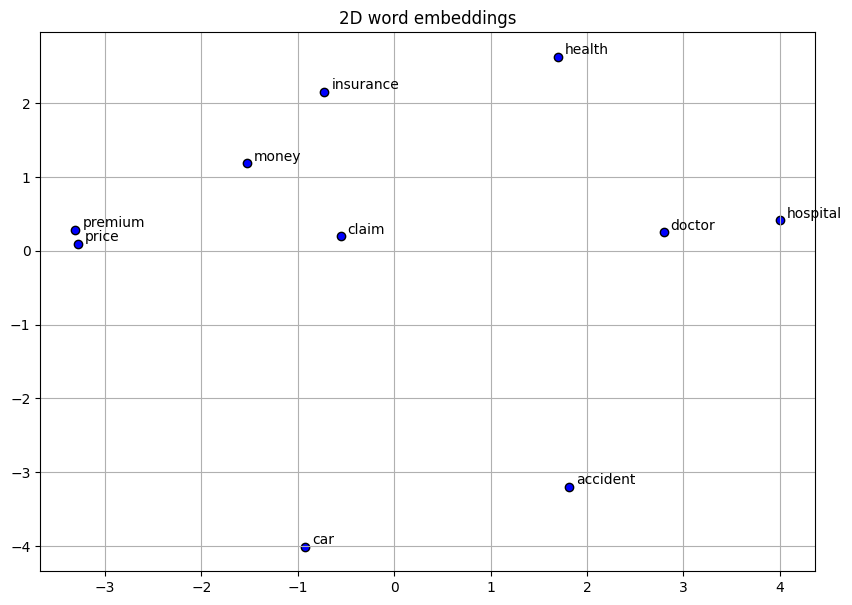

In [24]:
mots_assurance = ['insurance', 'money', 'car', 'accident', 'claim', 
                  'health', 'doctor', 'hospital', 'premium', 'price']
model_glove_en.plot_2d_embeddings(mots_assurance,"Test_word_2D_embeddings_glove_en")

In [25]:
word_to_test = "insurers"
similar_words = model_glove_en.getMostSimilar(word_to_test, 10)

print(f"The ten words most similar to '{word_to_test}' are :")
display(similar_words)

The ten words most similar to 'insurers' are :


['insurance',
 'hmos',
 'premiums',
 'insurer',
 'lenders',
 'providers',
 'corporations',
 'companies',
 'firms',
 'brokerages']

In [30]:
if dataset is None: 
    dataset = pd.DataFrame() #To not have None warnings
data_pour_globe_en = [ast.literal_eval(text) 
                        if isinstance(text, str) 
                        else text for text in dataset['tokens_en']]
corpus_vectors = [model_glove_en.get_sentence_vector(review) for review in data_pour_globe_en]
valid_data = {i: vec for i, vec in enumerate(corpus_vectors) if vec is not None}
clean_vectors_globe = list(valid_data.values())
clean_indices_globe = list(valid_data.keys())

In [29]:
query = "expensive insurance price"
indices = model_glove_en.semantic_search_fast(query, clean_vectors, top_n=3)

print(f"Top 3 for: '{query}'")
for i, idx in enumerate(indices):
    original_idx = clean_indices[idx]
    avis_texte = dataset['tokens_en'].iloc[original_idx]
    print(f"Avis n°{original_idx}: {avis_texte}")

Top 3 for: 'expensive insurance price'
Avis n°15929: ['expensive', 'mutual', 'reimbursement', 'relate', 'price']
Avis n°18928: ['far', 'expensive', 'service', 'call', 'part', 'insurer', 'offer', 'price', 'discount', 'competitive']
Avis n°11822: ['satisfied', 'give', 'high', 'price', 'policy', 'monthly', 'price', 'expensive', 'annual', 'price', 'police', 'compare', 'cheap', 'company']


<a id="topic_modeling"></a>
## 4 Topic Modeling

<a id="K_mean_cluster"></a>
### 4.1 K-mean Clustering

In [ ]:
class K_Mean_Modeler:
    def __init__(self, n_topics=5):
        self.n_topics = n_topics
        self.kmeans = KMeans(n_clusters=n_topics, random_state=42, n_init=10)
        self.topic_labels = {}

    def fit_predict(self, corpus_vectors):
        matrix = np.array(corpus_vectors)
        clusters = self.kmeans.fit_predict(matrix)
        return clusters

    def get_topic_keywords_glove(self, model_interface, top_n=20):

        centroids = self.kmeans.cluster_centers_
        topic_keywords = {}
        
        for i, center in enumerate(centroids):
            distances = np.dot(model_interface.vectors, center)
            closest_indices = np.argsort(distances)[-top_n:][::-1]
            words = [model_interface.getWord(idx) for idx in closest_indices]
            topic_keywords[i] = words
            
        self.topic_labels = topic_keywords
        return topic_keywords
    
    def get_topic_keywords_w2v(self, w2v_model_instance, top_n=20):
        if w2v_model_instance.model is None:
            print("Erreur : Le modèle Word2Vec n'est pas entraîné.")
            return None

        centroids = self.kmeans.cluster_centers_
        all_vectors = w2v_model_instance.model.wv.vectors    
        topic_keywords = {}
        
        for i, center in enumerate(centroids):
            similarities = np.dot(all_vectors, center)
            closest_indices = np.argsort(similarities)[-top_n:][::-1]
        
            words = [w2v_model_instance.getWord(idx) for idx in closest_indices]
            topic_keywords[i] = words
        
        self.topic_labels = topic_keywords
        return topic_keywords

In [52]:
data_en = [
    [word for word in (ast.literal_eval(text) if isinstance(text, str) else text)]
    for text in dataset['tokens_en']
]

data_fr = [
    [word for word in (ast.literal_eval(text) if isinstance(text, str) else text)]
    for text in dataset['tokens']
]

corpus_vectors = [model_glove_en.get_sentence_vector(review) for review in data_en]
valid_data = {i: vec for i, vec in enumerate(corpus_vectors) if vec is not None}
clean_vectors_globe = list(valid_data.values())
clean_indices_globe = list(valid_data.keys())

corpus_vectors = [model_w2v_en.get_sentence_vector(review) for review in data_en]
valid_data = {i: vec for i, vec in enumerate(corpus_vectors) if vec is not None}
clean_vectors_w2v_en = list(valid_data.values())
clean_indices_w2v_en = list(valid_data.keys())

corpus_vectors = [model_w2v_fr.get_sentence_vector(review) for review in data_fr]
valid_data = {i: vec for i, vec in enumerate(corpus_vectors) if vec is not None}
clean_vectors_w2v_fr = list(valid_data.values())
clean_indices_w2v_fr = list(valid_data.keys())

In [55]:
kmean_1 = K_Mean_Modeler(n_topics=5)
clusters_1 = kmean_1.fit_predict(clean_vectors_globe)

dataset['topic_glove_en'] = -1
for i, idx_original in enumerate(clean_indices_globe):
    dataset.loc[idx_original, 'topic_glove_en'] = clusters_1[i]

keywords = kmean_1.get_topic_keywords_glove(model_glove_en)
for topic, words in keywords.items():
    print(f"Topic {topic} : {', '.join(words)}")

Topic 0 : we, be, it, to, would, that, not, more, they, will, n't, if, this, have, their, you, could, its, i, any
Topic 1 : load, loads, loading, fuel, loaded, cargo, weight, maximum, engine, speed, capacity, velocity, storage, your, trucks, oxygen, freight, torque, payload, tons
Topic 2 : we, to, not, be, that, it, would, they, if, you, n't, will, any, could, their, i, do, this, have, more
Topic 3 : we, i, you, n't, do, not, be, if, they, our, it, that, my, what, ``, to, would, your, can, so
Topic 4 : we, be, you, not, it, more, if, that, n't, to, any, our, would, can, i, they, this, will, its, their


In [56]:
kmean_2 = K_Mean_Modeler(n_topics=5)
clusters_2 = kmean_2.fit_predict(clean_vectors_w2v_en)

dataset['topic_w2v_en'] = -1
for i, idx_original in enumerate(clean_indices_w2v_en):
    dataset.loc[idx_original, 'topic_w2v_en'] = clusters_2[i]

keywords = kmean_2.get_topic_keywords_w2v(model_w2v_en)
for topic, words in keywords.items():
    print(f"Topic {topic} : {', '.join(words)}")

Topic 0 : ease, intuitive, affordable, efficient, highly, ergonomic, quick, satisfied, loved, simplicity, practical, fast, easy, reasonable, rapidity, suit, competitive, interface, fluid, navigation
Topic 1 : affordable, loved, ease, competitive, relatively, efficient, intuitive, highly, reasonable, ergonomic, satisfied, suit, attractive, quick, qualityprice, price, inexpensive, interesting, fast, cheap
Topic 2 : acknowledgment, registered, loved, green, formal, ease, debit, surcharge, receipt, provisional, opposition, quick, relaunch, affordable, nickel, hesitation, efficient, confirmation, relatively, highly
Topic 3 : intuitive, interface, ergonomic, store, efficient, load, simplicity, stoppage, ease, practical, guide, convenience, download, speed, navigation, quick, super, functional, friendly, fast
Topic 4 : efficient, ease, highly, affordable, intuitive, loved, lamia, rapidity, pleasant, satisfied, quick, ergonomic, kindness, attentive, erika, fast, caroline, friendly, reasonable,

In [57]:
kmean_3 = K_Mean_Modeler(n_topics=5)
clusters_3 = kmean_3.fit_predict(clean_vectors_w2v_fr)

dataset['topic_w2v_fr'] = -1
for i, idx_original in enumerate(clean_indices_w2v_fr):
    dataset.loc[idx_original, 'topic_w2v_fr'] = clusters_3[i]

keywords = kmean_3.get_topic_keywords_w2v(model_w2v_fr)
for topic, words in keywords.items():
    print(f"Topic {topic} : {', '.join(words)}")

Topic 0 : satisfaite, agréable, rapidité, conviennent, sympathique, efficace, facilité, écoute, expliquées, chaleureux, intuitif, accueillant, recommanderais, accueil, abordable, rapide, convienne, qualitéprix, excellent, satisfait
Topic 1 : bris, conviennent, augmente, glace, bée, nickel, pare, convenable, passera, convienne, satisfaite, abordable, qualitéprix, recommanderais, brise, irréparable, verte, compétitif, verron, facilité
Topic 2 : conviennent, facilité, intuitif, rapidité, abordable, simplicité, satisfaite, convienne, rapide, satisfait, ergonomique, qualitéprix, efficace, convenable, recommanderais, ludique, expliquées, utilisation, navigation, fluide
Topic 3 : accusé, surtaxé, verte, conviennent, satisfaite, ergonomique, intuitif, facilité, nickel, opposition, convienne, qualitéprix, rapide, convenable, abordable, joindre, rapidité, ludique, recommanderais, fluide
Topic 4 : conviennent, intuitif, abordable, qualitéprix, satisfaite, convienne, facilité, convenable, satisfai

In [63]:
def plot_clusters_2d(vectors, cluster_labels, name: str = "Visualisation K-mean cluster",
                     title: str ="Embeddings clusters"):

    pca = PCA(n_components=2)
    coords = pca.fit_transform(vectors)

    df_plot = pd.DataFrame({
        'x': coords[:, 0],
        'y': coords[:, 1],
        'Topic': [f"Topic {label}" for label in cluster_labels]
    })
    

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_plot, 
        x='x', y='y', 
        hue='Topic', 
        palette='viridis', 
        alpha=0.6, 
        edgecolor=None
    )
    
    plt.title(title, fontsize=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.savefig(VISU_PATH / f"{name}.png", bbox_inches="tight")
    plt.show()

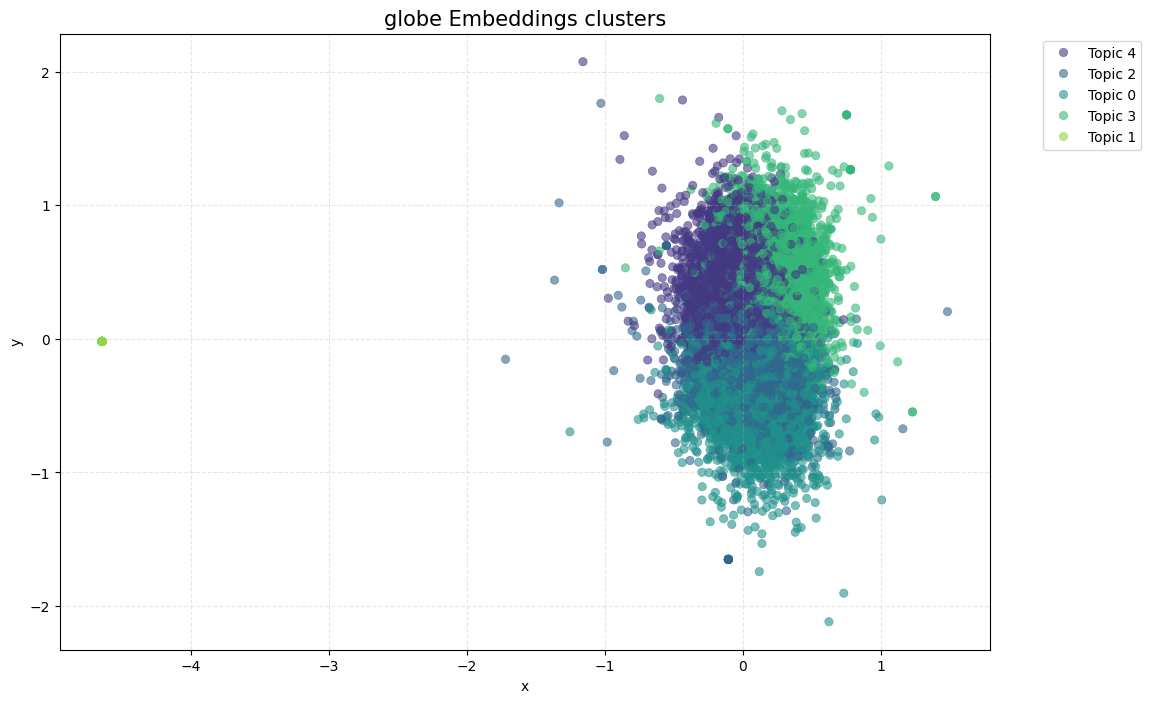

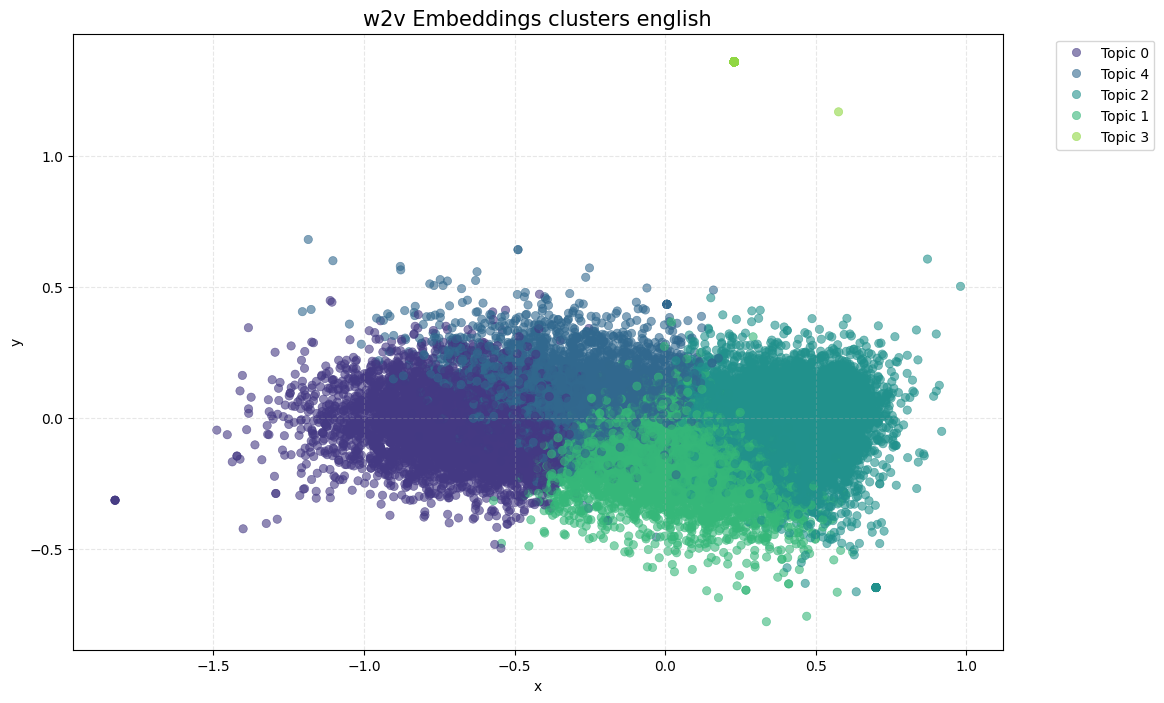

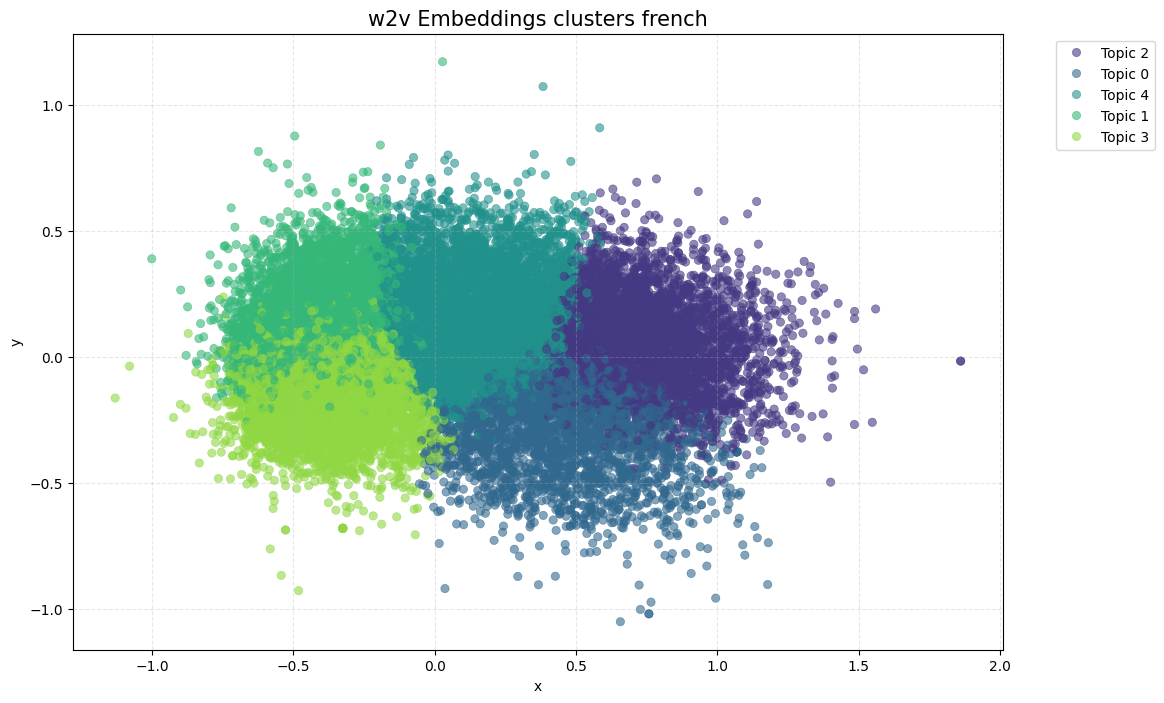

In [64]:
plot_clusters_2d(clean_vectors_globe, clusters_1,
                 "K_mean_globe_clusters","globe Embeddings clusters")
plot_clusters_2d(clean_vectors_w2v_en, clusters_2,
                 "K_mean_w2v_clusters_en","w2v Embeddings clusters english")
plot_clusters_2d(clean_vectors_w2v_fr, clusters_3,
                 "K_mean_w2v_clusters_fr","w2v Embeddings clusters french")



<a id="f"></a>
### 4.2 f